# Fitting Functions with Fourier Series

This notebook illustrates the least squares fitting of functions with a trigonometric basis.

The package FastGaussQuadrature provides nodes and weights for
the Gauss-Chebyshev quadrature rules.

In [1]:
using FastGaussQuadrature

In [2]:
using Plots

In [3]:
using Printf

### 1. The Orthogonal Basis of Trigonometric Functions

The inner product requires the numerical evaluation of integrals.  To evaluate the integrals, we apply Gauss-Legendre quadrature.  The weights and the nodes ar provided by the package ``FastGaussQuadrature``.

In [4]:
nodes, weights = gausslegendre(32)
for i = 1:32
    println(nodes[i], " : ", weights[i])
end

-0.9972638618494816 : 0.007018610009470092
-0.9856115115452684 : 0.016274394730905625
-0.9647622555875065 : 0.025392065309262146
-0.9349060759377397 : 0.03427386291302135
-0.8963211557660521 : 0.042835898022226614
-0.84936761373257 : 0.05099805926237613
-0.7944837959679424 : 0.05868409347853559
-0.7321821187402897 : 0.06582222277636192
-0.6630442669302152 : 0.07234579410884852
-0.5877157572407623 : 0.07819389578707032
-0.5068999089322294 : 0.08331192422694678
-0.42135127613063533 : 0.08765209300440385
-0.33186860228212767 : 0.09117387869576388
-0.23928736225213706 : 0.09384439908080452
-0.1444719615827965 : 0.09563872007927489
-0.048307665687738324 : 0.09654008851472778
0.048307665687738324 : 0.09654008851472778
0.1444719615827965 : 0.09563872007927489
0.23928736225213706 : 0.09384439908080452
0.33186860228212767 : 0.09117387869576388
0.42135127613063533 : 0.08765209300440385
0.5068999089322294 : 0.08331192422694678
0.5877157572407623 : 0.07819389578707032
0.6630442669302152 : 0.072345

In [5]:
rule(f) = sum([weights[k]*f(nodes[k]) for k=1:length(weights)])

rule (generic function with 1 method)

The ``rule`` is applied in the definition of the inner product function below.

In [6]:
"""
    function innerproduct(f::Function, g::Function)

returns the value of the inner product of the functions f and g,
by the integral of f and g over [-1,+1].
"""
function innerproduct(f::Function, g::Function)
    fun(x) = f(x)*g(x)
    return rule(fun)
end

innerproduct

The ``innerproduct`` will be tested on the verification of the orthogonality of the basis.

In [7]:
"""
    function basis(n::Int64)

returns an array of functions with the first 2*n+1 basis functions.
"""
function basis(n::Int64)
    one = [(t) -> 1]
    sines = [(t) -> sin(k*pi*t) for k=1:n]
    cosines = [(t) -> cos(k*pi*t) for k=1:n]
    result = [one; sines; cosines]
    return result
end

basis

As ``basis`` returns an array of functions, there is not much to see, but we can use the functions in a plot.
Let us look at the first five basis functions.

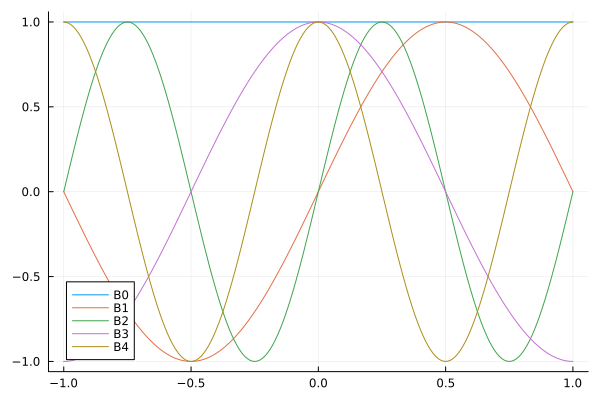

In [8]:
B5 = basis(2)
xr = -1:0.01:1
yr1 = [B5[1](t) for t in xr]
yr2 = [B5[2](t) for t in xr]
yr3 = [B5[3](t) for t in xr]
yr4 = [B5[4](t) for t in xr]
yr5 = [B5[5](t) for t in xr]
plot(xr,yr1,label="B0")
plot!(xr,yr2,label="B1")
plot!(xr,yr3,label="B2")
plot!(xr,yr4,label="B3")
plot!(xr,yr5,label="B4")

In [9]:
# savefig("fourierbasis5.png")

The verification of the orthogonality is defined by the function below.

In [10]:
"""
    function orthogonality(n::Int64)

Verifies the orthogonality
for the first 2*n+1 basis polynomials.
Prints the matrix of all inner products.
"""
function orthogonality(n::Int64)
    b = basis(n)
    dim = 2*n+1
    for i=1:dim
        for j=1:dim
            ip = innerproduct(b[i],b[j])
            ipstr = @sprintf("%+.2e", ip)
            print(" $ipstr")
        end
        println("")
    end
end

orthogonality

In [11]:
orthogonality(2)

 +2.00e+00 +9.16e-17 -2.64e-18 +3.17e-16 -3.57e-16
 +9.16e-17 +1.00e+00 -9.37e-17 +2.64e-17 +1.83e-17
 -2.64e-18 -9.37e-17 +1.00e+00 +2.09e-18 +4.49e-18
 +3.17e-16 +2.64e-17 +2.09e-18 +1.00e+00 +2.62e-16
 -3.57e-16 +1.83e-17 +4.49e-18 +2.62e-16 +1.00e+00


We observe the identity matrix (modulo roundoff of machine precision), except for the first number in the first row and column, which equals ``2``.

### 2. Computing the Least Squares Approximation

For any function $f$ and the first $2 n+1$ basis functions, the polynomial approximation $p$ of degree $2n+1$ is

$$
    p(t) = \frac{a_0}{2} 
         + \sum_{k=0}^n \left( \vphantom{\frac{a_0}{2}}
                a_k \cos(k \pi t) + b_k \sin(k \pi t) \right),
$$

where the coefficients are the inner products of $f$ with the basis functions:

$$
    a_0 = \langle f, 1 \rangle,
$$

$$
    a_k = \langle f, \cos(k \pi t) \rangle, \quad k=1,2,\ldots,n,
$$

$$
    b_k = \langle f, \sin(k \pi t) \rangle, \quad k=1,2,\ldots,n.
$$

The coefficients of the approximation are computed by the function below.

In [12]:
"""
    function coefficients(f::Function,b::Array{Function,1})

returns the inner products of f with the basis functions in b.
"""
function coefficients(f::Function,b::Array{Function,1})
    dim = length(b)
    result = zeros(dim)
    for i=1:dim
        result[i] = innerproduct(f,b[i])
    end
    return result
end

coefficients

With the coefficients and the array of basis functions, we can define the function for the approximant.

In [13]:
"""
    function approximation(c::Array{Float64,1},b::Array{Function,1})

Given in c are the coefficients of the Chebyshev approximation
with the basis functions in f.
Returns the approximation as a function.
"""
function approximation(c::Array{Float64,1},b::Array{Function,1})
    first(x) = c[1]*b[1](x)/2
    rest(x) = sum([c[k]*b[k](x) for k=2:length(c)])
    result(x) = first(x) + rest(x)
    return result
end

approximation

Let us compute the least squares approximation of $(\sin(2 \pi t))^3$ for $t \in [-1,1]$ of degree 7, or $n=3$.

In [14]:
f(t) = (sin(2*pi*t))^3
b3 = basis(3)
c3 = coefficients(f, b3)

7-element Vector{Float64}:
 -8.744874026571803e-18
 -1.4346993204495304e-16
  0.7500000000000001
 -1.441209547749919e-16
  3.9532417311787286e-18
 -5.12958520645774e-18
 -4.482586368886933e-17

Observe that many of the coefficients are below machine precision.

In [15]:
a3 = approximation(c3,b3)

(::var"#result#approximation##4"{var"#rest#approximation##1"{Vector{Float64}, Vector{Function}}, var"#first#approximation##0"{Vector{Float64}, Vector{Function}}}) (generic function with 1 method)

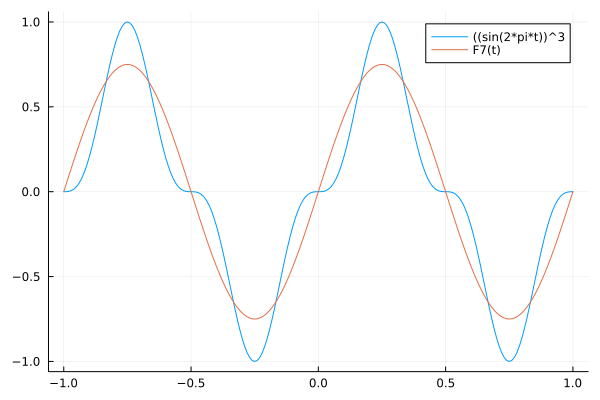

In [16]:
xr = -1.0:0.01:1.0
fx = [f(t) for t in xr]
px = [a3(t) for t in xr]
plot(xr,fx,label="((sin(2*pi*t))^3",legend=:topright)
plot!(xr,px,label="F7(t)")

In [17]:
# savefig("trigonometricapp7sin3.png")

Let us make a plot of the error.   

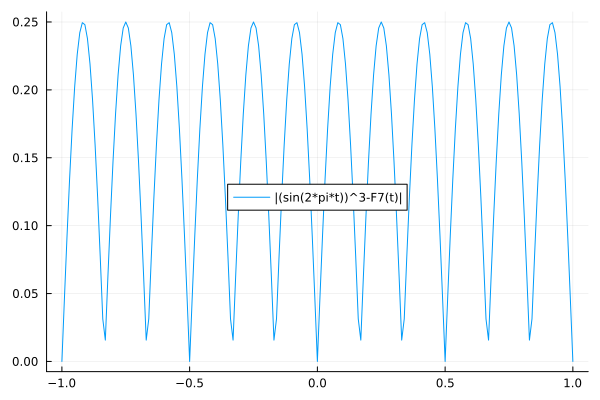

In [18]:
errors = [abs(f(t) - a3(t)) for t in xr]
plot(xr, errors, label="|(sin(2*pi*t))^3-F7(t)|",legend=:inside)

In [19]:
# savefig("trigonometricerr7sin3.png")

In [20]:
b6 = basis(6)
c6 = coefficients(f, b6)

13-element Vector{Float64}:
 -8.744874026571803e-18
 -1.4346993204495304e-16
  0.7500000000000001
 -1.441209547749919e-16
 -2.3198680413195323e-15
 -4.4729931373818793e-13
 -0.25000000004608725
  3.9532417311787286e-18
 -5.12958520645774e-18
 -4.482586368886933e-17
  2.767253991701839e-17
  7.131289496942162e-19
 -8.08138914852057e-18

In [21]:
a6 = approximation(c6,b6)

(::var"#result#approximation##4"{var"#rest#approximation##1"{Vector{Float64}, Vector{Function}}, var"#first#approximation##0"{Vector{Float64}, Vector{Function}}}) (generic function with 1 method)

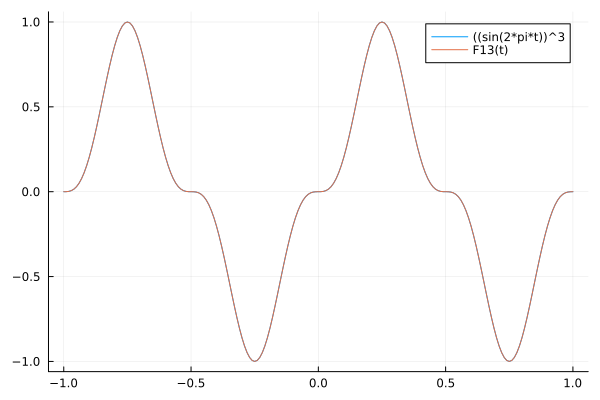

In [22]:
xr = -1.0:0.01:1.0
fx = [f(t) for t in xr]
px = [a6(t) for t in xr]
plot(xr,fx,label="((sin(2*pi*t))^3",legend=:topright)
plot!(xr,px,label="F13(t)")

In [23]:
# savefig("trigonometricapp13sin3.png")

Let us focus on the largest coefficients in the Fourier series approximation.

In [24]:
argc6 = [Int(abs(t) > 0.01) for t in c6]

13-element Vector{Int64}:
 0
 0
 1
 0
 0
 0
 1
 0
 0
 0
 0
 0
 0

In [25]:
println(c6[3])
println(c6[7])

0.7500000000000001
-0.25000000004608725


Only two basis functions matter, with coefficients 0.75 and -0.25.

In [26]:
g(t) = 0.75*sin(2*pi*t) - 0.25*cos(pi*t)

g (generic function with 1 method)

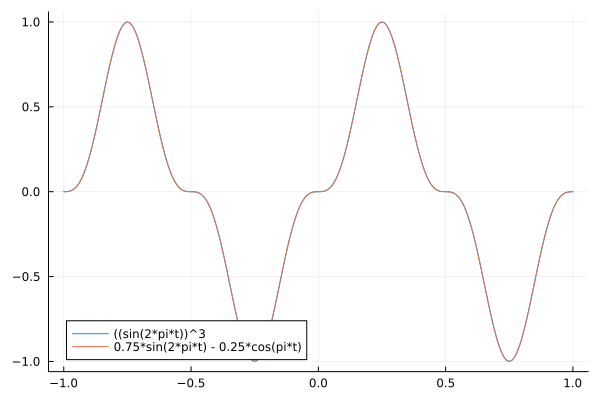

In [27]:
xr = -1.0:0.01:1.0
fx = [f(t) for t in xr]
gx = [g(t) for t in xr]
plot(xr,fx,label="((sin(2*pi*t))^3",legend=:bottomleft)
plot!(xr,px,label="0.75*sin(2*pi*t) - 0.25*cos(pi*t)")

In [28]:
# savefig("trigonometricresult.png")

We did some numeric-symbolic computations, ending up with a symbolic result.